# Translate text to simple 2D image

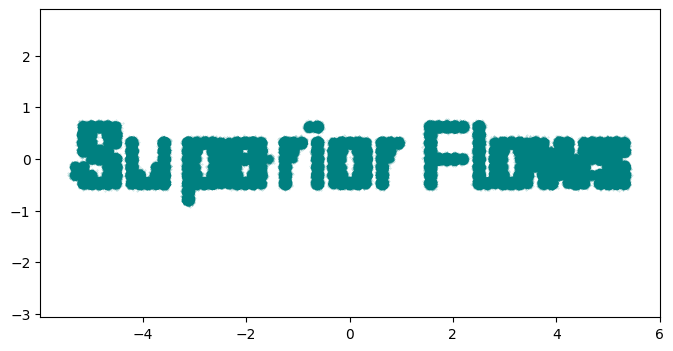

In [29]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont


def generate_smooth_grains(key, text, n_samples=20000, grid_size=128, sigma=0.5):
    # 1. Create the mask (as before)
    img = Image.new('L', (grid_size, grid_size), color=0)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", int(grid_size * 0.7))
    except:
        font = ImageFont.load_default()

    w, h = draw.textbbox((0, 0), text, font=font)[2:]
    draw.text(((grid_size-w)/2, (grid_size-h)/2), text, fill=255, font=font)

    # 2. Convert to probability distribution
    pdf = jnp.array(img, dtype=jnp.float32)
    pdf /= pdf.sum()

    # Split the PRNGKey for different stochastic operations
    k1, k2, k3 = jax.random.split(key, 3)

    # 3. Discrete sampling of pixel indices
    flat_indices = jax.random.choice(k1, jnp.arange(grid_size**2), shape=(n_samples,), p=pdf.ravel())
    y = (flat_indices // grid_size).astype(jnp.float32)
    x = (flat_indices % grid_size).astype(jnp.float32)

    # 4. DE-QUANTIZATION (The "Smooth" part)
    # Add noise within the width of one pixel [0, 1]
    # x_noise = jax.random.uniform(k2, shape=(n_samples,))
    # y_noise = jax.random.uniform(k3, shape=(n_samples,))
    x_noise = jax.random.normal(k2, shape=(n_samples,))
    y_noise = jax.random.normal(k3, shape=(n_samples,))

    x = x + sigma * x_noise
    y = y + sigma * y_noise

    # 5. Normalise to physics coordinates [-1, 1]
    coords = jnp.stack([x, y], axis=1)
    coords = (coords / grid_size) * 2 - 1
    coords = coords.at[:, 1].set(-coords[:, 1]) # Flip Y

    return coords

# Let's generate a very dense set of grains
key = jax.random.key(0)
dense_grains = 10*generate_smooth_grains(key, "Superior Flows", n_samples=10_000_000, sigma=0.2)

plt.figure(figsize=(8, 4))
plt.scatter(dense_grains[:, 0], dense_grains[:, 1], s=0.1, color='teal', alpha=0.3)
plt.axis('equal')
plt.show()

In [107]:
from pathlib import Path

import diffrax as dfx
import distrax as dsx
import equinox as eqx
import grain
import jax
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import optax

from superiorflows import Flow
from superiorflows.train import (
    MaximumLikelihoodLoss,
    ProgressBarCallback,
    Trainer,
)


class MLPVelocity(eqx.Module):
    """MLP velocity field with time conditioning."""

    mlp: eqx.nn.MLP

    def __init__(self, input_dim: int, width: int, depth: int, *, key):
        self.mlp = eqx.nn.MLP(
            in_size=input_dim + 1,
            out_size=input_dim,
            width_size=width,
            depth=depth,
            activation=jax.nn.tanh,
            key=key,
        )

    @eqx.filter_jit
    def __call__(self, t, x, args):
        t_feat = jnp.broadcast_to(t, x.shape[:-1] + (1,))
        return self.mlp(jnp.concatenate([x, t_feat], axis=-1))

key = jax.random.key(42)
d = 2
base_dist = dsx.MultivariateNormalDiag(jnp.zeros(d), jnp.ones(d))
flow_kwargs = dict(stepsize_controller=dfx.PIDController(rtol=1e-5, atol=1e-5))
loss_fn = MaximumLikelihoodLoss(base_distribution=base_dist, **flow_kwargs)
width = 64
depth = 3
key, subkey = jax.random.split(key)
model = MLPVelocity(input_dim=d, width=width, depth=depth, key=subkey)

batch_size = 256
train_loader = (
    grain.MapDataset.source(dense_grains)
    .shuffle(seed=10)
    # .to_iter_dataset()
    .batch(batch_size=batch_size)
)

optimizer = optax.adam(1e-3)
trainer = Trainer(
        model=model,
        optimizer=optimizer,
        loss_module=loss_fn,
        seed=42,
        callbacks=[ProgressBarCallback(refresh_rate=50)],
    )

max_steps = 5000
model = trainer.train(train_loader=train_loader, max_steps=max_steps)

Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Training: 100%|██████████| 5000/5000 [07:56<00:00, 10.48it/s, loss=1.0625]


In [111]:
n_particles = 1_000_000
n_frames = 40
save_times = jnp.linspace(0.0, 1.0, n_frames)

key, subkey = jax.random.split(key)
x0 = base_dist.sample(seed=subkey, sample_shape=(n_particles,))

# Integrate methods
def get_trajectories(model):
    flow = Flow(velocity_field=model, base_distribution=base_dist)
    return jax.vmap(lambda x: flow.integrate(x, saveat=dfx.SaveAt(ts=save_times)).ys)(x0)

trajectory = get_trajectories(model)

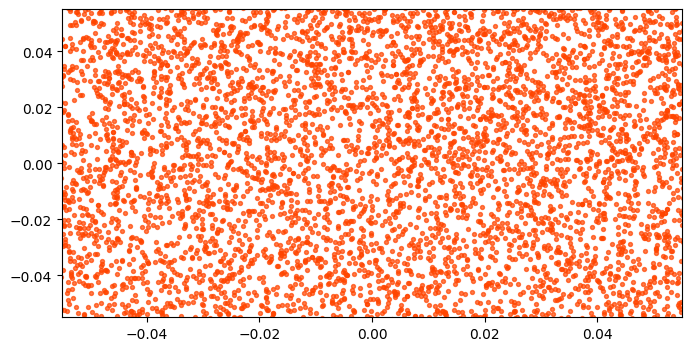

In [112]:
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
scatter = ax.scatter([], [], s=8, c="orangered", alpha=0.7)

# Adjust limits to fit your actual data range
# ax.set_xlim(-1.5, 1.5)
# ax.set_ylim(-1.5, 1.5)
# ax.set_aspect("equal")

def init():
    scatter.set_offsets(np.empty((0, 2)))
    return (scatter,)

def animate(frame):
    # trajectory shape is likely (n_particles, n_frames, 2)
    # So we take all particles at this specific frame
    data = trajectory[:, frame, :]
    scatter.set_offsets(data)
    return (scatter,)

ani = animation.FuncAnimation(
    fig, animate, init_func=init, frames=n_frames,
    interval=80, blit=True
)

# Using a meaningful path for your new project
output_dir = Path("experiments")
output_dir.mkdir(parents=True, exist_ok=True)
ani.save(output_dir / "logo.gif", writer="pillow", fps=15)